# CAPSTONE PROJECT ON SOCIODEMOGRAPHIC TRENDS IN VIOLENCE AGAINST WOMEN.

## Analysis, Prediction and Decision Support System Using Python, Machine Learning and Flask.

##### Business Problem:

Violence against women remains a major social challenge affecting health, safety, economic development, and human rights. 

Government agencies, NGOs, researchers, and policymakers require data-driven insights to understand trends, identify vulnerable groups, predict violence patterns, and formulate interventions. 

The objective of this project is to analyze historical data on violence against women, identify key sociodemographic factors associated with violence incidents and fatalities, develop predictive models, and deploy a decision-support web application.

#### Importing the libraries:

In [1]:
import pandas as pd
import numpy as np

### STAGE 1: DATA INSPECTION

##### Loading the dataset:

In [2]:
df = pd.read_csv("D:/datasets/Sociodemographic_Trends_in_Womens_Violence.csv")

##### Viewing the first rows:

In [3]:
df.head()

,Year,Violence Type,Incident Count,Death Count,Victim Age,Literate Scale
0,2010,Rape,810,66,25-30,Low
1,2011,Rape,1040,96,31<,Low
2,2012,Rape,904,106,0-18,Low
3,2013,Rape,1128,94,25-30,Medium
4,2014,Rape,1054,99,25-30,Medium


##### Checking the dimensions:

In [4]:
df.shape

(195, 6)

##### Dataset information:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            195 non-null    int64 
 1   Violence Type   195 non-null    object
 2   Incident Count  195 non-null    int64 
 3   Death Count     195 non-null    int64 
 4   Victim Age      195 non-null    object
 5   Literate Scale  195 non-null    object
dtypes: int64(3), object(3)
memory usage: 9.3+ KB


##### Checking data types:

In [6]:
df.dtypes

Year               int64
Violence Type     object
Incident Count     int64
Death Count        int64
Victim Age        object
Literate Scale    object
dtype: object

##### Missing values:

In [7]:
df.isnull().sum()

Year              0
Violence Type     0
Incident Count    0
Death Count       0
Victim Age        0
Literate Scale    0
dtype: int64

##### Duplicate rows:

In [8]:
df.duplicated().sum()

0

##### Summary statistics:

In [9]:
df.describe()

,Year,Incident Count,Death Count
count,195.000000,195.000000,195.000000
mean,2017.000000,282.728205,97.948718
std,4.331615,370.575177,202.061431
min,2010.000000,0.000000,0.000000
25%,2013.000000,29.000000,0.000000
50%,2017.000000,115.000000,8.000000
75%,2021.000000,410.000000,64.000000
max,2024.000000,1957.000000,1118.000000


### STAGE 2: DATA CLEANING

##### Creating a copy of the original dataset

In [10]:
df_clean = df.copy()

##### Checking for inconsistent text values:

In [11]:
df_clean["Violence Type"].unique()

array(['Rape', 'Domestic Worker Abuse', 'Dowry', 'Acid Attack', 'Burnt ',
       'Sexual Harrasment', 'Early Marriage', 'Women Trafficking',
       'Rejection Based Violence', 'Societal Coercion',
       'Police Brutality', 'Lethal Violence ',
       'Misuse of Religious Edicts'], dtype=object)

In [12]:
df_clean["Victim Age"].unique()

array(['25-30', '31<', '0-18', '19-24'], dtype=object)

In [13]:
df_clean["Literate Scale"].unique()

array(['Low', 'Medium', 'High'], dtype=object)

##### Removing extra spaces:

In [14]:
categorical_cols = ["Violence Type", "Victim Age", "Literate Scale"]

for col in categorical_cols:
    df_clean[col] = df_clean[col].str.strip()

##### Standardize capitalization:

In [15]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].str.title()

##### Inspect zero values:

In [16]:
(df_clean["Incident Count"] == 0).sum()

5

In [17]:
(df_clean["Death Count"] == 0).sum()

80

##### Viewing the records:

In [18]:
df_clean[df_clean["Incident Count"] == 0]

,Year,Violence Type,Incident Count,Death Count,Victim Age,Literate Scale
26,2021,Domestic Worker Abuse,0,0,19-24,High
132,2022,Rejection Based Violence,0,0,0-18,High
133,2023,Rejection Based Violence,0,0,0-18,High
134,2024,Rejection Based Violence,0,0,25-30,High
161,2021,Police Brutality,0,0,0-18,High


In [19]:
df_clean[df_clean["Death Count"] == 0]

,Year,Violence Type,Incident Count,Death Count,Victim Age,Literate Scale
26,2021,Domestic Worker Abuse,0,0,19-24,High
27,2022,Domestic Worker Abuse,13,0,19-24,High
50,2015,Acid Attack,37,0,25-30,Medium
57,2022,Acid Attack,22,0,0-18,High
58,2023,Acid Attack,8,0,25-30,High
...,...,...,...,...,...,...
190,2020,Misuse Of Religious Edicts,8,0,25-30,High
191,2021,Misuse Of Religious Edicts,2,0,25-30,High
192,2022,Misuse Of Religious Edicts,9,0,0-18,High
193,2023,Misuse Of Religious Edicts,12,0,25-30,High


##### Checking for impossible values:

In [20]:
(df_clean["Incident Count"] < 0).any()

False

In [21]:
(df_clean["Death Count"] < 0).any()

False

##### Verifying data types:

In [22]:
df_clean.dtypes

Year               int64
Violence Type     object
Incident Count     int64
Death Count        int64
Victim Age        object
Literate Scale    object
dtype: object

##### For better readability:

In [23]:
df_clean["Victim Age"] = df_clean["Victim Age"].replace({
    "31<": "31+"
})

In [24]:
df_clean.to_csv("clean_womens_violence.csv", index=False)

### STAGE 3: FEATURE ENGINEERING

##### Creating new variables to make later analysis and machine learning model more informative

In [25]:
df_clean["Decade"] = (df_clean["Year"] // 10) * 10

In [26]:
df_clean[["Year", "Decade"]].head(10)

,Year,Decade
0,2010,2010
1,2011,2010
2,2012,2010
3,2013,2010
4,2014,2010
5,2015,2010
6,2016,2010
7,2017,2010
8,2018,2010
9,2019,2010


In [27]:
df_clean["Year Category"] = np.where(
    df_clean["Year"] < 2015,
    "Early",
    "Recent"
)

In [28]:
df_clean[["Year", "Year Category"]].head(10)

,Year,Year Category
0,2010,Early
1,2011,Early
2,2012,Early
3,2013,Early
4,2014,Early
5,2015,Recent
6,2016,Recent
7,2017,Recent
8,2018,Recent
9,2019,Recent


In [29]:
conditions = [
    df_clean["Incident Count"] < 500,
    (df_clean["Incident Count"] >= 500) &
    (df_clean["Incident Count"] < 1000),
    df_clean["Incident Count"] >= 1000
]

choices = ["Low", "Medium", "High"]

df_clean["Severity"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

In [30]:
df_clean[["Incident Count", "Severity"]].head(15)

,Incident Count,Severity
0,810,Medium
1,1040,High
2,904,Medium
3,1128,High
4,1054,High
5,1234,High
6,1215,High
7,1431,High
8,1070,High
9,1957,High


In [31]:
df_clean["Fatality Rate"] = np.where(
    df_clean["Incident Count"] == 0,
    0,
    df_clean["Death Count"] / df_clean["Incident Count"]
)

In [32]:
df_clean[
    ["Incident Count",
     "Death Count",
     "Fatality Rate"]
].head(15)

,Incident Count,Death Count,Fatality Rate
0,810,66,0.081481
1,1040,96,0.092308
2,904,106,0.117257
3,1128,94,0.083333
4,1054,99,0.093928
5,1234,85,0.068882
6,1215,44,0.036214
7,1431,58,0.040531
8,1070,63,0.058879
9,1957,96,0.049055


In [33]:
age_map = {
    "0-18": "Child",
    "19-24": "Young Adult",
    "25-30": "Young Adult",
    "31+": "Adult"
}

df_clean["Age Risk Group"] = df_clean["Victim Age"].map(age_map)

In [34]:
df_clean[
    ["Victim Age", "Age Risk Group"]
].drop_duplicates()

,Victim Age,Age Risk Group
0,25-30,Young Adult
1,31+,Adult
2,0-18,Child
9,19-24,Young Adult


In [35]:
df_clean.head()

,Year,Violence Type,Incident Count,Death Count,Victim Age,Literate Scale,Decade,Year Category,Severity,Fatality Rate,Age Risk Group
0,2010,Rape,810,66,25-30,Low,2010,Early,Medium,0.081481,Young Adult
1,2011,Rape,1040,96,31+,Low,2010,Early,High,0.092308,Adult
2,2012,Rape,904,106,0-18,Low,2010,Early,Medium,0.117257,Child
3,2013,Rape,1128,94,25-30,Medium,2010,Early,High,0.083333,Young Adult
4,2014,Rape,1054,99,25-30,Medium,2010,Early,High,0.093928,Young Adult


### STAGE 4: UNIVARIATE ANALYSIS

#### Exploring one variable at a time in order to understand the distribution of every feature

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [37]:
violence_counts = df_clean["Violence Type"].value_counts()

violence_counts

Violence Type
Rape                          15
Domestic Worker Abuse         15
Dowry                         15
Acid Attack                   15
Burnt                         15
Sexual Harrasment             15
Early Marriage                15
Women Trafficking             15
Rejection Based Violence      15
Societal Coercion             15
Police Brutality              15
Lethal Violence               15
Misuse Of Religious Edicts    15
Name: count, dtype: int64

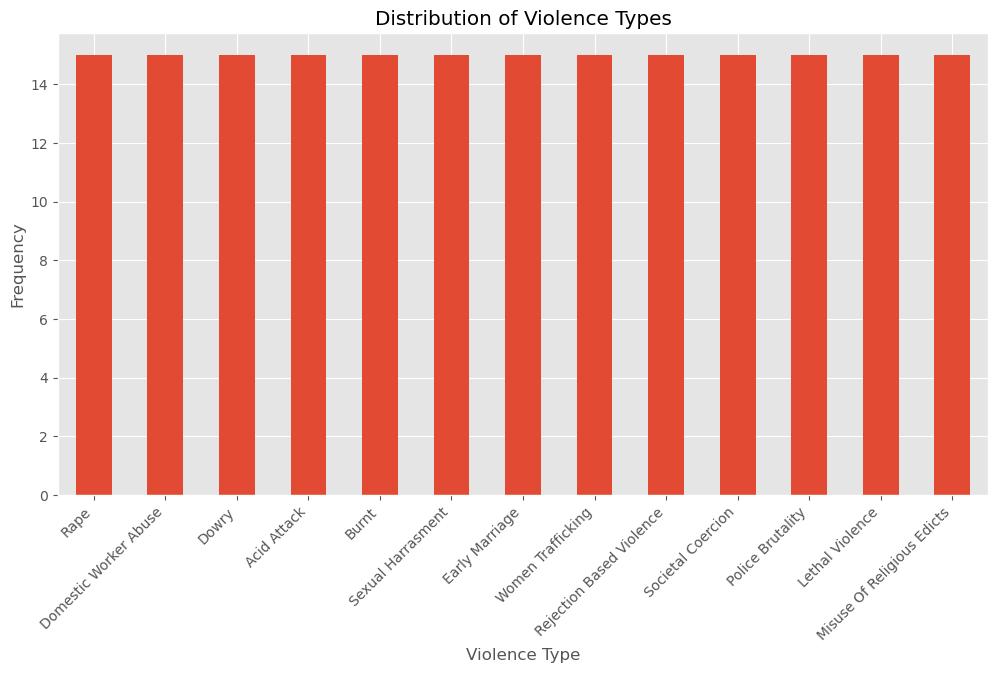

In [38]:
plt.figure(figsize=(12,6))

violence_counts.plot(kind="bar")

plt.title("Distribution of Violence Types")
plt.xlabel("Violence Type")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")

plt.show()

In [39]:
age_counts = df_clean["Age Risk Group"].value_counts()

age_counts

Age Risk Group
Young Adult    97
Adult          53
Child          45
Name: count, dtype: int64

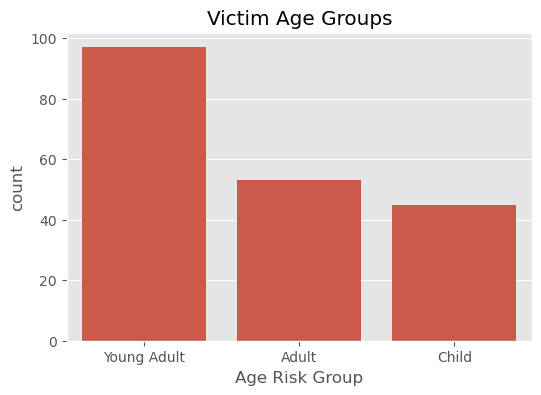

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_clean, x="Age Risk Group")

plt.title("Victim Age Groups")

plt.show()

In [41]:
literacy_counts = df_clean["Literate Scale"].value_counts()

literacy_counts

Literate Scale
High      91
Medium    65
Low       39
Name: count, dtype: int64

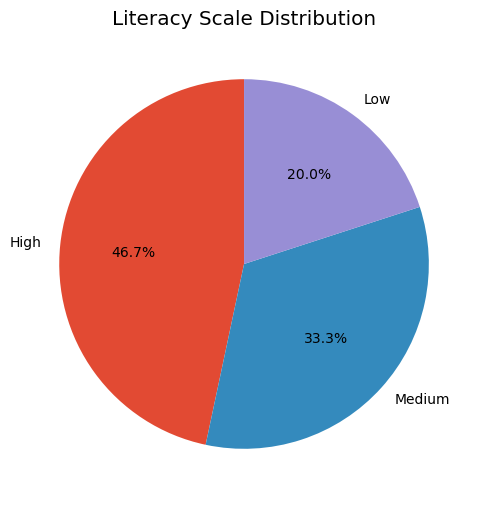

In [42]:
plt.figure(figsize=(6,6))

plt.pie(
    literacy_counts,
    labels=literacy_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Literacy Scale Distribution")

plt.show()

In [43]:
severity_counts = df_clean["Severity"].value_counts()

severity_counts

Severity
Low       153
Medium     28
High       14
Name: count, dtype: int64

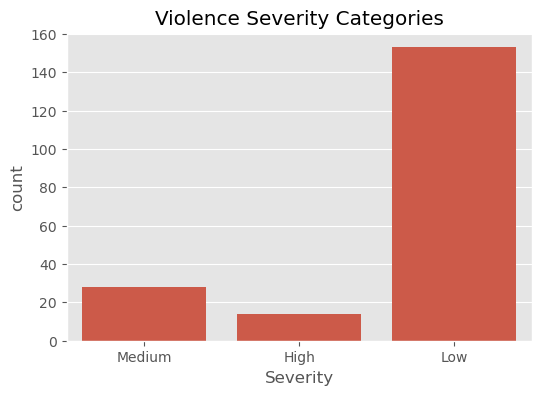

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_clean, x="Severity")

plt.title("Violence Severity Categories")

plt.show()

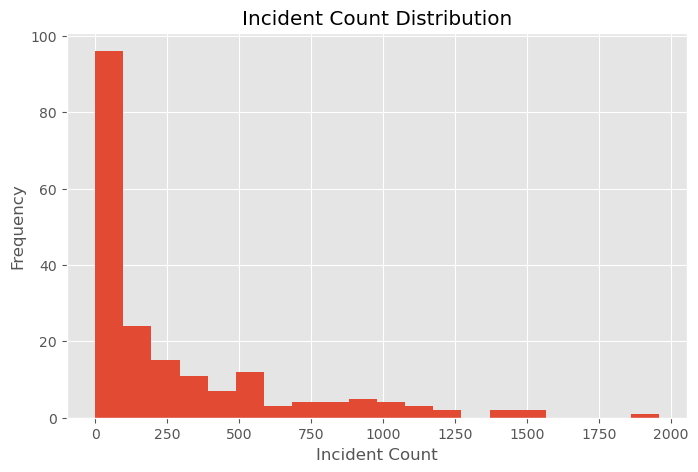

In [45]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["Incident Count"], bins=20)

plt.title("Incident Count Distribution")
plt.xlabel("Incident Count")
plt.ylabel("Frequency")

plt.show()

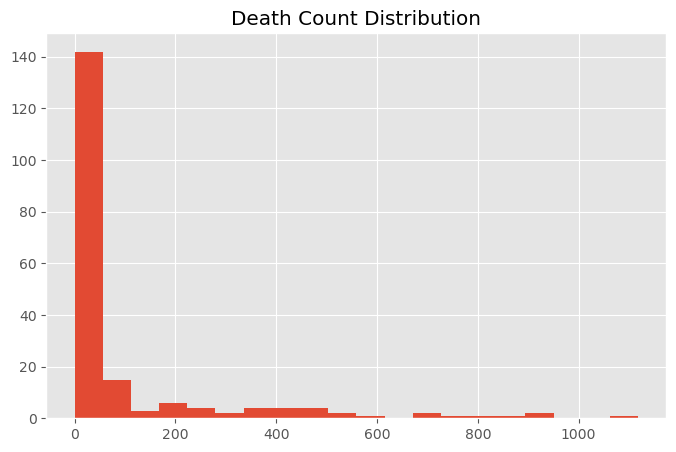

In [46]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["Death Count"], bins=20)

plt.title("Death Count Distribution")

plt.show()

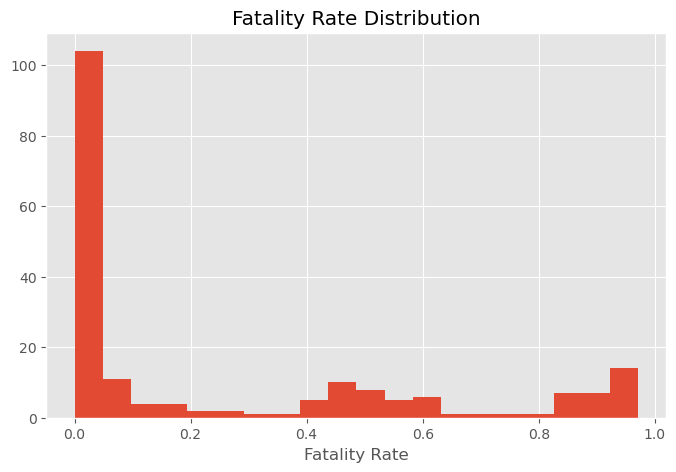

In [47]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["Fatality Rate"], bins=20)

plt.title("Fatality Rate Distribution")

plt.xlabel("Fatality Rate")

plt.show()

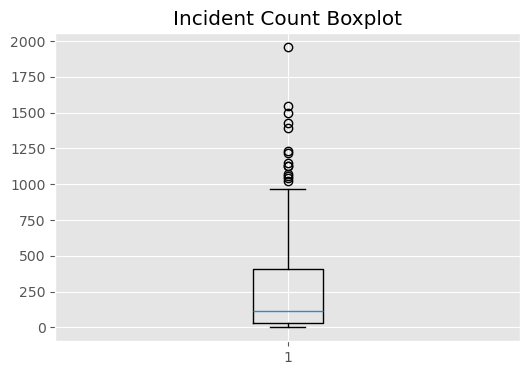

In [48]:
plt.figure(figsize=(6,4))

plt.boxplot(df_clean["Incident Count"])

plt.title("Incident Count Boxplot")

plt.show()

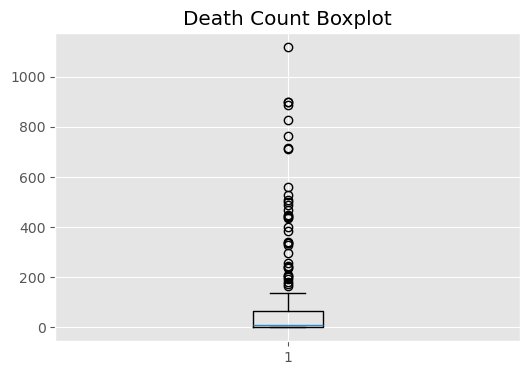

In [49]:
plt.figure(figsize=(6,4))

plt.boxplot(df_clean["Death Count"])

plt.title("Death Count Boxplot")

plt.show()

#### For the machine learning model later, it's helpful to make the severity column an ordered categorical variable:

In [50]:
df_clean["Severity"] = pd.Categorical(
    df_clean["Severity"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

#### Fixing spelling error:

In [51]:
df_clean["Violence Type"] = df_clean["Violence Type"].replace(
    "Sexual Harrasment",
    "Sexual Harassment"
)

### STAGE 5: BIVARIATE ANALYSIS 

In [52]:
violence_incidents = (
    df_clean.groupby("Violence Type")["Incident Count"]
    .sum()
    .sort_values(ascending=False)
)

violence_incidents

Violence Type
Rape                          17253
Lethal Violence               11056
Sexual Harassment              8190
Societal Coercion              5139
Dowry                          4390
Women Trafficking              3579
Early Marriage                 2397
Burnt                           833
Domestic Worker Abuse           785
Acid Attack                     629
Misuse Of Religious Edicts      370
Police Brutality                283
Rejection Based Violence        228
Name: Incident Count, dtype: int64

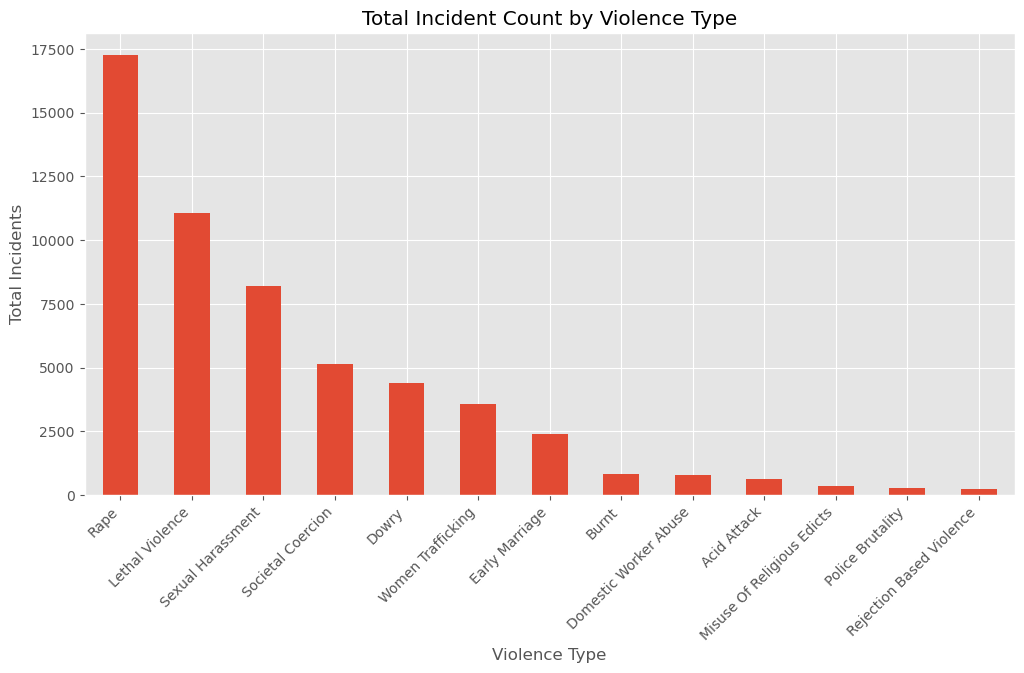

In [53]:
plt.figure(figsize=(12,6))

violence_incidents.plot(kind="bar")

plt.title("Total Incident Count by Violence Type")
plt.xlabel("Violence Type")
plt.ylabel("Total Incidents")

plt.xticks(rotation=45, ha="right")

plt.show()

In [54]:
violence_deaths = (
    df_clean.groupby("Violence Type")["Death Count"]
    .sum()
    .sort_values(ascending=False)
)

violence_deaths

Violence Type
Lethal Violence               10316
Societal Coercion              4510
Dowry                          2219
Rape                           1004
Domestic Worker Abuse           452
Burnt                           328
Sexual Harassment               233
Acid Attack                      38
Early Marriage                    0
Misuse Of Religious Edicts        0
Police Brutality                  0
Rejection Based Violence          0
Women Trafficking                 0
Name: Death Count, dtype: int64

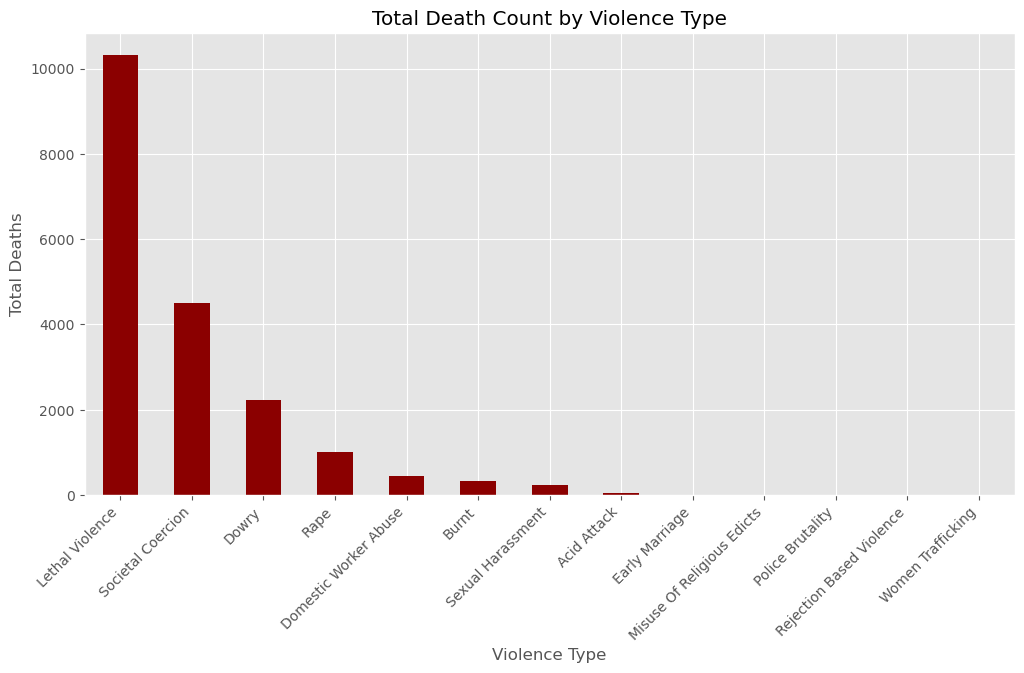

In [55]:
plt.figure(figsize=(12,6))

violence_deaths.plot(kind="bar", color="darkred")

plt.title("Total Death Count by Violence Type")
plt.xlabel("Violence Type")
plt.ylabel("Total Deaths")

plt.xticks(rotation=45, ha="right")

plt.show()

In [56]:
literacy_incidents = (
    df_clean.groupby("Literate Scale")["Incident Count"]
    .sum()
)

literacy_incidents

Literate Scale
High      19961
Low       14873
Medium    20298
Name: Incident Count, dtype: int64

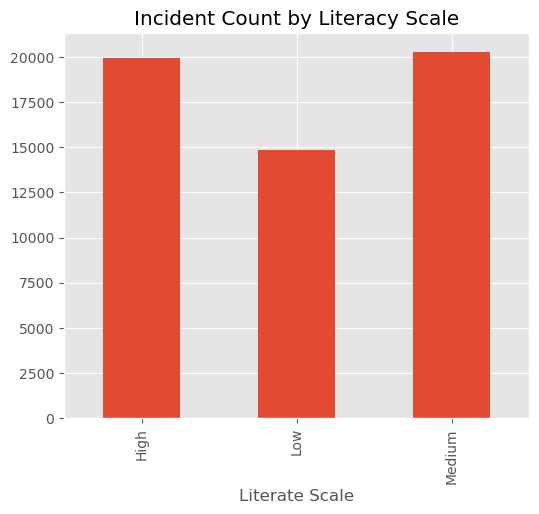

In [57]:
plt.figure(figsize=(6,5))

literacy_incidents.plot(kind="bar")

plt.title("Incident Count by Literacy Scale")

plt.show()

In [58]:
literacy_deaths = (
    df_clean.groupby("Literate Scale")["Death Count"]
    .sum()
)

literacy_deaths

Literate Scale
High      5913
Low       5594
Medium    7593
Name: Death Count, dtype: int64

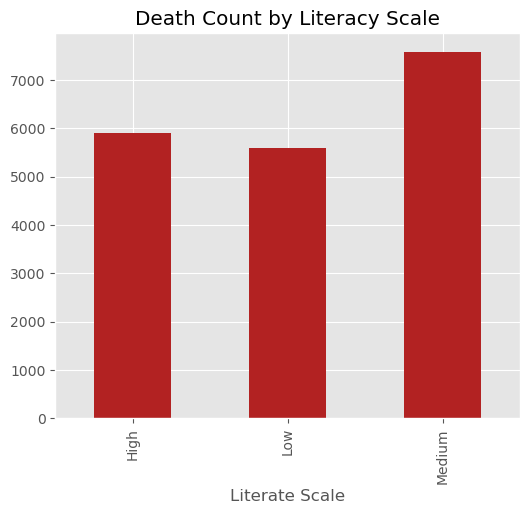

In [59]:
plt.figure(figsize=(6,5))

literacy_deaths.plot(kind="bar", color="firebrick")

plt.title("Death Count by Literacy Scale")

plt.show()

In [60]:
age_incidents = (
    df_clean.groupby("Age Risk Group")["Incident Count"]
    .sum()
)

age_incidents

Age Risk Group
Adult          15340
Child          12584
Young Adult    27208
Name: Incident Count, dtype: int64

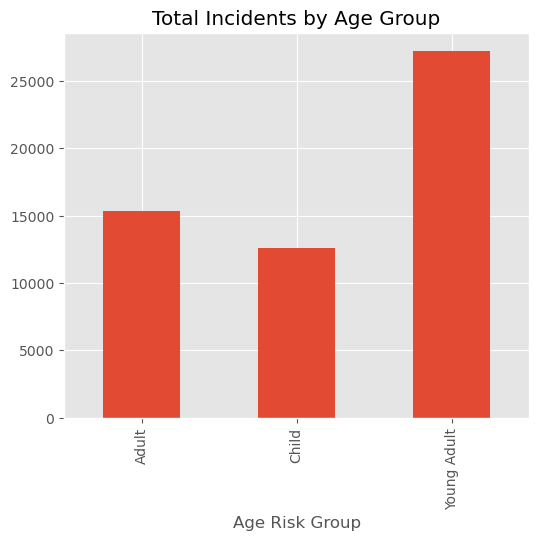

In [61]:
plt.figure(figsize=(6,5))

age_incidents.plot(kind="bar")

plt.title("Total Incidents by Age Group")

plt.show()

In [62]:
age_deaths = (
    df_clean.groupby("Age Risk Group")["Death Count"]
    .sum()
)

age_deaths

Age Risk Group
Adult          5235
Child          6013
Young Adult    7852
Name: Death Count, dtype: int64

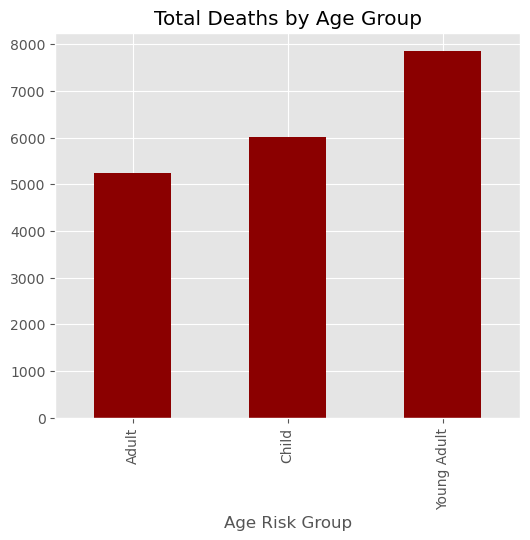

In [63]:
plt.figure(figsize=(6,5))

age_deaths.plot(kind="bar", color="darkred")

plt.title("Total Deaths by Age Group")

plt.show()

In [64]:
year_incidents = (
    df_clean.groupby("Year")["Incident Count"]
    .sum()
)

year_incidents

Year
2010    5074
2011    5351
2012    4448
2013    4073
2014    3999
2015    3769
2016    3944
2017    4513
2018    3122
2019    3930
2020    2948
2021    2983
2022    2791
2023    2242
2024    1945
Name: Incident Count, dtype: int64

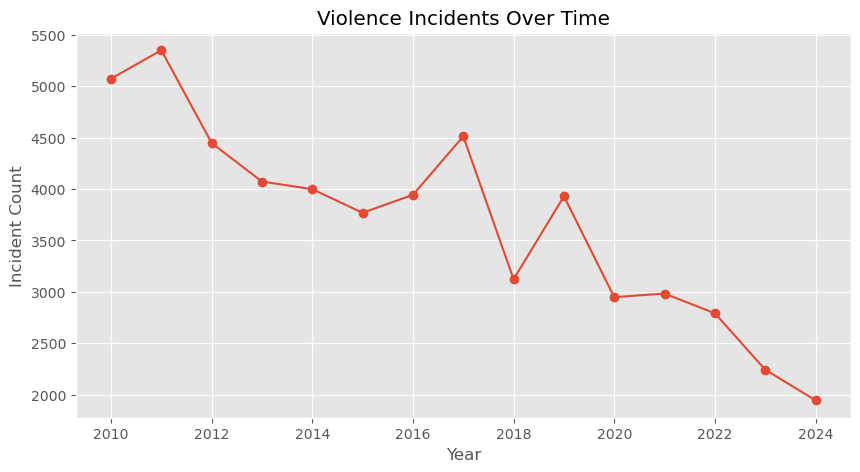

In [65]:
plt.figure(figsize=(10,5))

plt.plot(
    year_incidents.index,
    year_incidents.values,
    marker="o"
)

plt.title("Violence Incidents Over Time")
plt.xlabel("Year")
plt.ylabel("Incident Count")

plt.grid(True)

plt.show()

In [66]:
year_deaths = (
    df_clean.groupby("Year")["Death Count"]
    .sum()
)

year_deaths

Year
2010    1851
2011    1900
2012    1843
2013    1666
2014    1688
2015    1417
2016    1383
2017    1439
2018    1009
2019     967
2020     744
2021     663
2022     839
2023     881
2024     810
Name: Death Count, dtype: int64

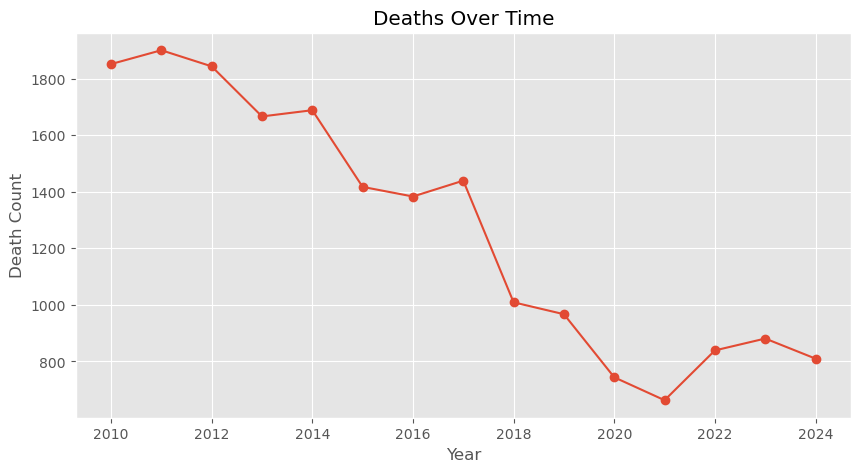

In [67]:
plt.figure(figsize=(10,5))

plt.plot(
    year_deaths.index,
    year_deaths.values,
    marker="o"
)

plt.title("Deaths Over Time")
plt.xlabel("Year")
plt.ylabel("Death Count")

plt.grid(True)

plt.show()

In [68]:
pivot = pd.pivot_table(
    df_clean,
    values="Incident Count",
    index="Violence Type",
    columns="Age Risk Group",
    aggfunc="sum"
)

pivot

Age Risk Group,Adult,Child,Young Adult
Violence Type,,,
Acid Attack,268.0,39.0,322.0
Burnt,163.0,251.0,419.0
Domestic Worker Abuse,447.0,127.0,211.0
Dowry,1110.0,1836.0,1444.0
Early Marriage,781.0,266.0,1350.0
Lethal Violence,2829.0,2507.0,5720.0
Misuse Of Religious Edicts,NaN,105.0,265.0
Police Brutality,22.0,121.0,140.0
Rape,2884.0,3550.0,10819.0


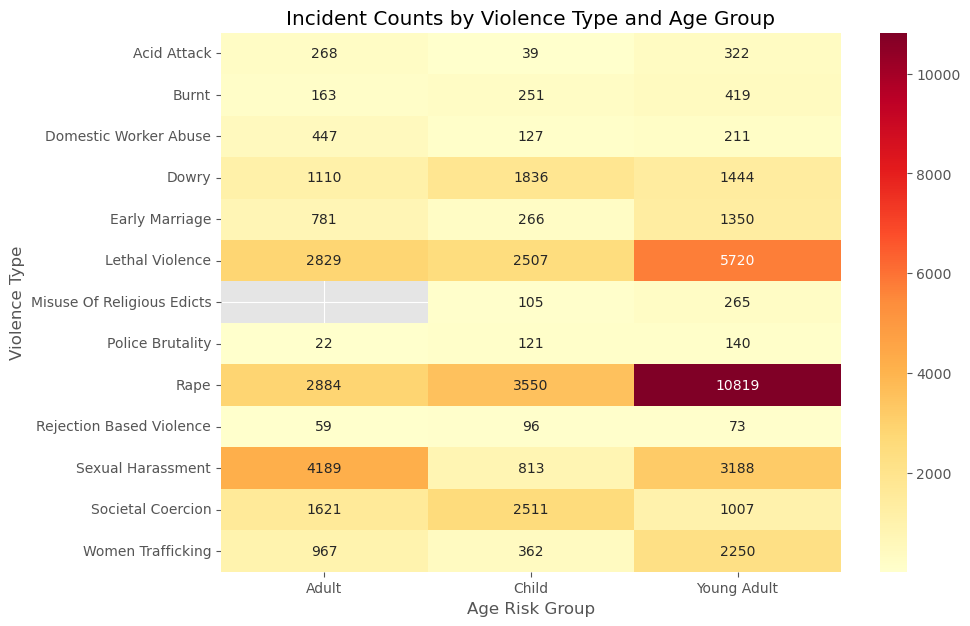

In [69]:
plt.figure(figsize=(10,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Incident Counts by Violence Type and Age Group")

plt.show()

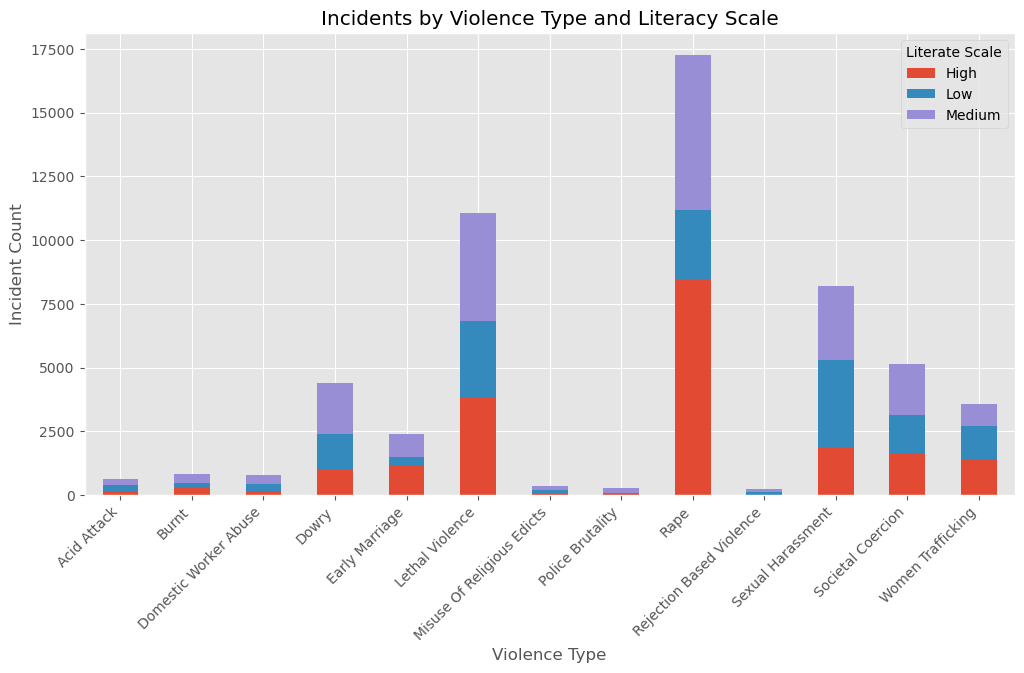

In [70]:
stacked = pd.pivot_table(
    df_clean,
    values="Incident Count",
    index="Violence Type",
    columns="Literate Scale",
    aggfunc="sum"
)

stacked.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Incidents by Violence Type and Literacy Scale")

plt.ylabel("Incident Count")

plt.xticks(rotation=45, ha="right")

plt.show()

### STAGE 6: MULTIVARIATE ANALYSIS

In [71]:
numeric_df = df_clean[[
    "Year",
    "Incident Count",
    "Death Count",
    "Fatality Rate"
]]

numeric_df.corr()

,Year,Incident Count,Death Count,Fatality Rate
Year,1.000000,-0.182575,-0.156297,-0.044260
Incident Count,-0.182575,1.000000,0.468159,0.204015
Death Count,-0.156297,0.468159,1.000000,0.778516
Fatality Rate,-0.044260,0.204015,0.778516,1.000000


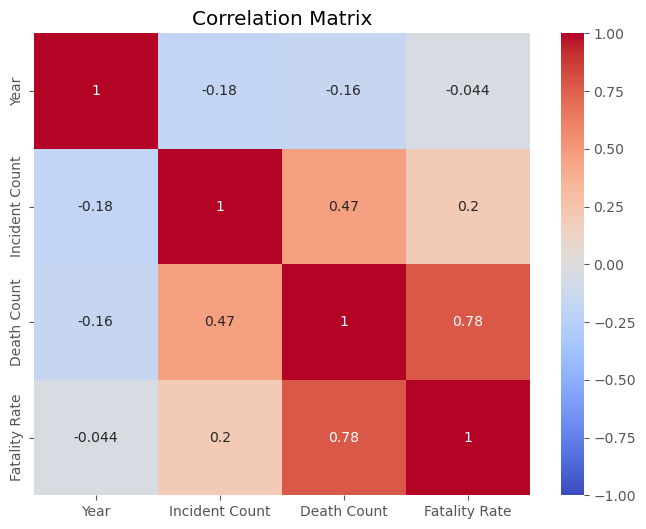

In [72]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")

plt.show()

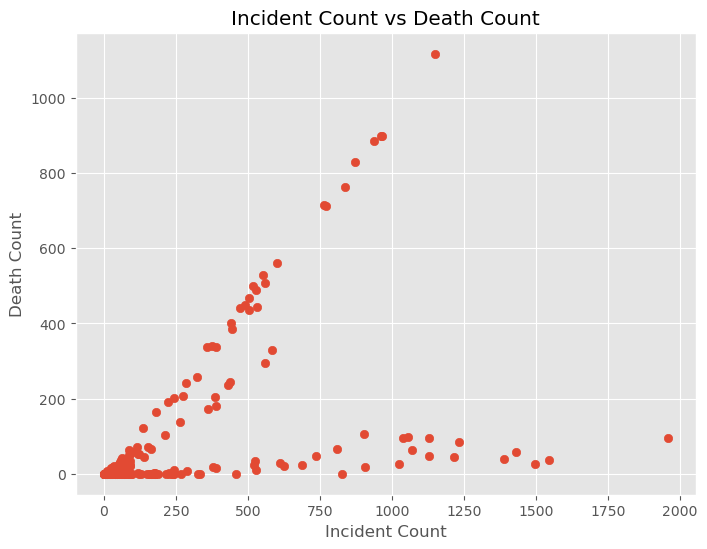

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["Incident Count"],
    df_clean["Death Count"]
)

plt.xlabel("Incident Count")
plt.ylabel("Death Count")
plt.title("Incident Count vs Death Count")

plt.show()

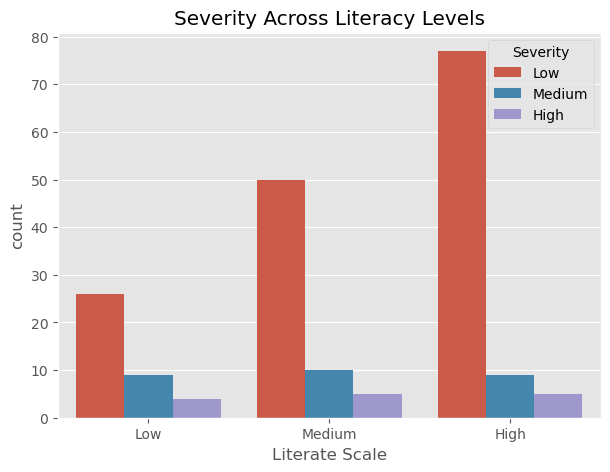

In [74]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Literate Scale",
    hue="Severity"
)

plt.title("Severity Across Literacy Levels")

plt.show()

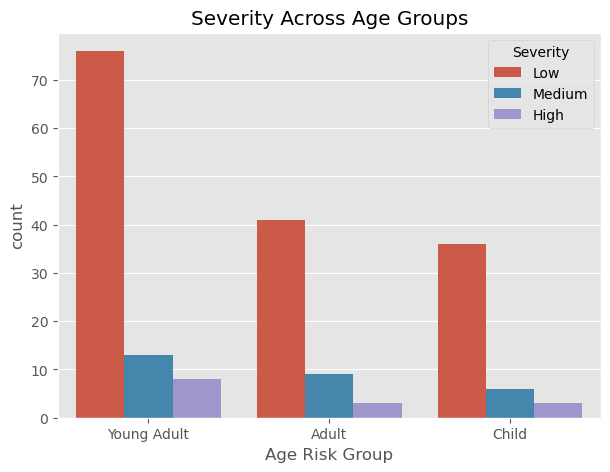

In [75]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Age Risk Group",
    hue="Severity"
)

plt.title("Severity Across Age Groups")

plt.show()

In [76]:
avg_fatality = (
    df_clean.groupby("Violence Type")["Fatality Rate"]
    .mean()
    .sort_values(ascending=False)
)

avg_fatality

Violence Type
Lethal Violence               0.930082
Societal Coercion             0.872319
Dowry                         0.479810
Domestic Worker Abuse         0.466927
Burnt                         0.417898
Acid Attack                   0.074854
Rape                          0.061732
Sexual Harassment             0.028069
Early Marriage                0.000000
Misuse Of Religious Edicts    0.000000
Police Brutality              0.000000
Rejection Based Violence      0.000000
Women Trafficking             0.000000
Name: Fatality Rate, dtype: float64

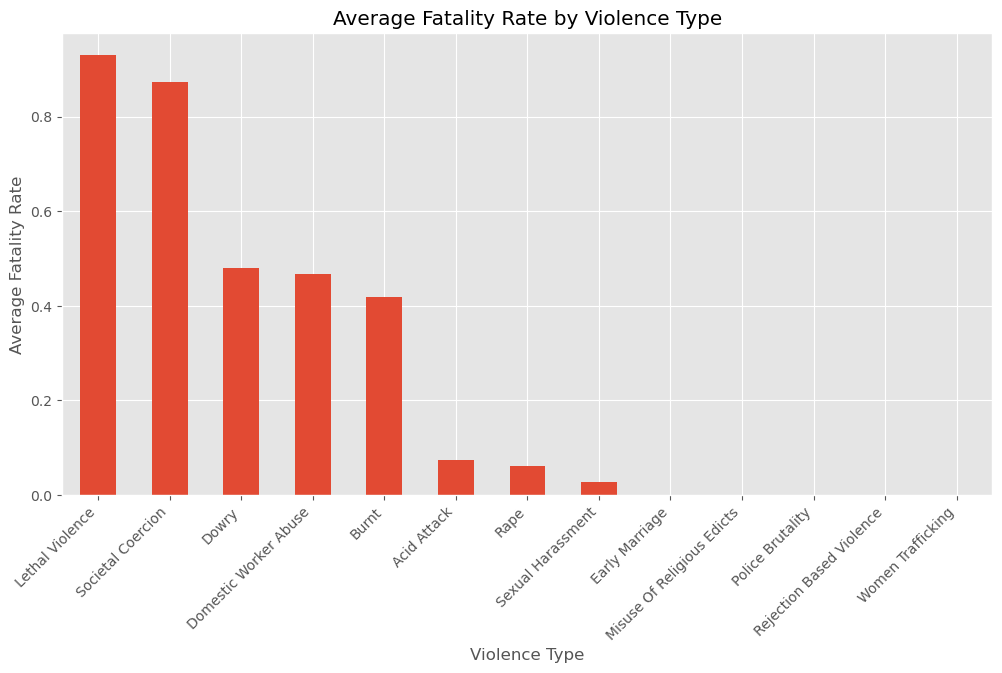

In [77]:
plt.figure(figsize=(12,6))

avg_fatality.plot(kind="bar")

plt.title("Average Fatality Rate by Violence Type")

plt.ylabel("Average Fatality Rate")

plt.xticks(rotation=45, ha="right")

plt.show()

In [78]:
pivot = pd.pivot_table(
    df_clean,
    values="Incident Count",
    index="Age Risk Group",
    columns="Literate Scale",
    aggfunc="sum"
)

pivot

Literate Scale,High,Low,Medium
Age Risk Group,,,
Adult,4168,5809,5363
Child,2042,4632,5910
Young Adult,13751,4432,9025


In [79]:
severity_table = pd.crosstab(
    df_clean["Age Risk Group"],
    df_clean["Severity"]
)

severity_table

Severity,Low,Medium,High
Age Risk Group,,,
Adult,41,9,3
Child,36,6,3
Young Adult,76,13,8


### STAGE 7: MACHINE LEARNING

In [80]:
features = [
    "Year",
    "Violence Type",
    "Victim Age",
    "Literate Scale",
    "Death Count",
    "Fatality Rate",
    "Year Category",
    "Age Risk Group",
    "Decade"
]

In [81]:
target = "Severity"

In [82]:
X = df_clean[features]
y = df_clean[target]

##### Encoding categorical variables

In [83]:
X.dtypes

Year                int64
Violence Type      object
Victim Age         object
Literate Scale     object
Death Count         int64
Fatality Rate     float64
Year Category      object
Age Risk Group     object
Decade              int64
dtype: object

In [84]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [85]:
X.head()

,Year,Death Count,Fatality Rate,Decade,Violence Type_Burnt,Violence Type_Domestic Worker Abuse,Violence Type_Dowry,Violence Type_Early Marriage,Violence Type_Lethal Violence,Violence Type_Misuse Of Religious Edicts,...,Violence Type_Societal Coercion,Violence Type_Women Trafficking,Victim Age_19-24,Victim Age_25-30,Victim Age_31+,Literate Scale_Low,Literate Scale_Medium,Year Category_Recent,Age Risk Group_Child,Age Risk Group_Young Adult
0,2010,66,0.081481,2010,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
1,2011,96,0.092308,2010,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
2,2012,106,0.117257,2010,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,2013,94,0.083333,2010,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
4,2014,99,0.093928,2010,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True


##### Encoding the target

In [86]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [87]:
dict(zip(label_encoder.classes_,
         label_encoder.transform(label_encoder.classes_)))

{'High': 0, 'Low': 1, 'Medium': 2}

##### Train-Test Split

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##### Scaling the features 

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

##### Verifying shapes

In [90]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (156, 24)
Testing Features: (39, 24)
Training Labels: (156,)
Testing Labels: (39,)


In [91]:
X = X.astype(int)
X.head()

,Year,Death Count,Fatality Rate,Decade,Violence Type_Burnt,Violence Type_Domestic Worker Abuse,Violence Type_Dowry,Violence Type_Early Marriage,Violence Type_Lethal Violence,Violence Type_Misuse Of Religious Edicts,...,Violence Type_Societal Coercion,Violence Type_Women Trafficking,Victim Age_19-24,Victim Age_25-30,Victim Age_31+,Literate Scale_Low,Literate Scale_Medium,Year Category_Recent,Age Risk Group_Child,Age Risk Group_Young Adult
0,2010,66,0,2010,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
1,2011,96,0,2010,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
2,2012,106,0,2010,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3,2013,94,0,2010,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
4,2014,99,0,2010,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1


### STAGE 8: MODEL DEVELOPMENT

##### Importing models

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

##### Importing evaluation metrics

In [93]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

#### MODEL 1: LOGISTIC REGRESSION

In [94]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [95]:
lr_pred = lr.predict(X_test_scaled)

In [96]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print("Accuracy:", lr_accuracy)

Accuracy: 0.8717948717948718


##### Classification report

In [97]:
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       1.00      0.67      0.80         3
         Low       0.91      0.97      0.94        31
      Medium       0.50      0.40      0.44         5

    accuracy                           0.87        39
   macro avg       0.80      0.68      0.73        39
weighted avg       0.86      0.87      0.86        39



##### Confusion matrix:

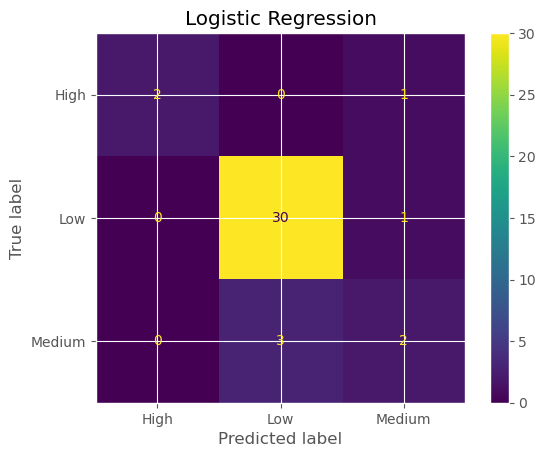

In [98]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=label_encoder.classes_
)

plt.title("Logistic Regression")

plt.show()

#### MODEL 2: DECISION TREE

In [99]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=5, random_state=42)

##### Prediction: 

In [100]:
tree_pred = tree.predict(X_test)

##### Accuracy:

In [101]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print(tree_accuracy)

0.8974358974358975


##### Classification Report:

In [102]:
print(
    classification_report(
        y_test,
        tree_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.75      1.00      0.86         3
         Low       0.97      0.94      0.95        31
      Medium       0.60      0.60      0.60         5

    accuracy                           0.90        39
   macro avg       0.77      0.85      0.80        39
weighted avg       0.90      0.90      0.90        39



##### Confusion matrix: 

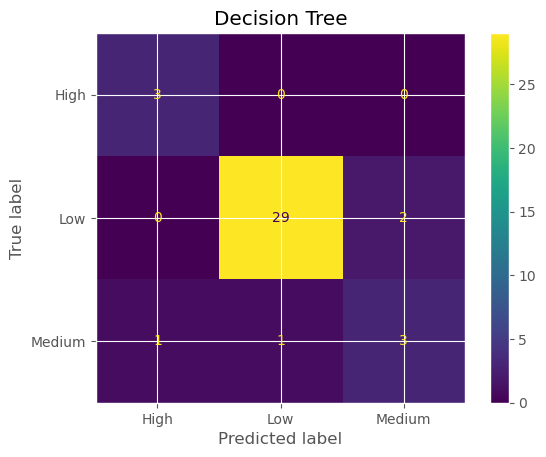

In [103]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred,
    display_labels=label_encoder.classes_
)

plt.title("Decision Tree")

plt.show()

#### MODEL 3: RANDOM FOREST

In [104]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

##### Prediction: 

In [105]:
rf_pred = rf.predict(X_test)

##### Accuracy:

In [106]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(rf_accuracy)

0.9230769230769231


##### Classification Report:

In [107]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       0.91      1.00      0.95        31
      Medium       1.00      0.40      0.57         5

    accuracy                           0.92        39
   macro avg       0.97      0.80      0.84        39
weighted avg       0.93      0.92      0.91        39



##### Confusion matrix:

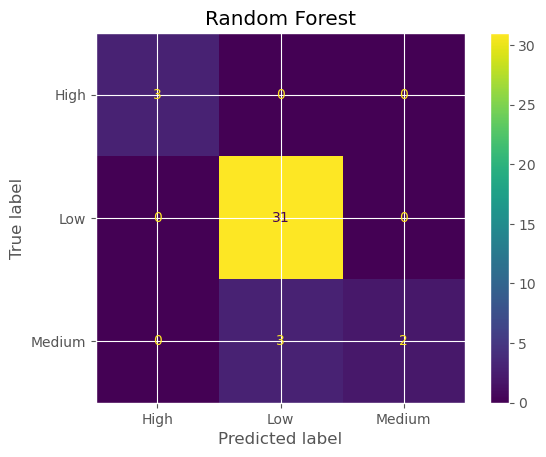

In [108]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=label_encoder.classes_
)

plt.title("Random Forest")

plt.show()

#### COMPARING MODELS:

In [109]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        tree_accuracy,
        rf_accuracy
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.923077
1,Decision Tree,0.897436
0,Logistic Regression,0.871795


#### COMPARING CLASSIFICATION REPORTS:

### STAGE 9: MODEL EVALUATION AND FINAL CONCLUSIONS:

##### Comparing model performance:

In [110]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.923077
1,Decision Tree,0.897436
0,Logistic Regression,0.871795


In [111]:
results["Accuracy"] = results["Accuracy"].round(3)
results

,Model,Accuracy
0,Logistic Regression,0.872
1,Decision Tree,0.897
2,Random Forest,0.923


In [112]:
results.style.highlight_max(
    subset=["Accuracy"],
    color="lightgreen"
)

,Model,Accuracy
0,Logistic Regression,0.872000
1,Decision Tree,0.897000
2,Random Forest,0.923000


#### FEATURE IMPORTANCE (Random Forest):

In [113]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Death Count,0.204473
2,Fatality Rate,0.189888
11,Violence Type_Rape,0.170803
8,Violence Type_Lethal Violence,0.128568
0,Year,0.082279
13,Violence Type_Sexual Harassment,0.061693
19,Literate Scale_Low,0.016041
22,Age Risk Group_Child,0.014826
20,Literate Scale_Medium,0.013847
17,Victim Age_25-30,0.013227


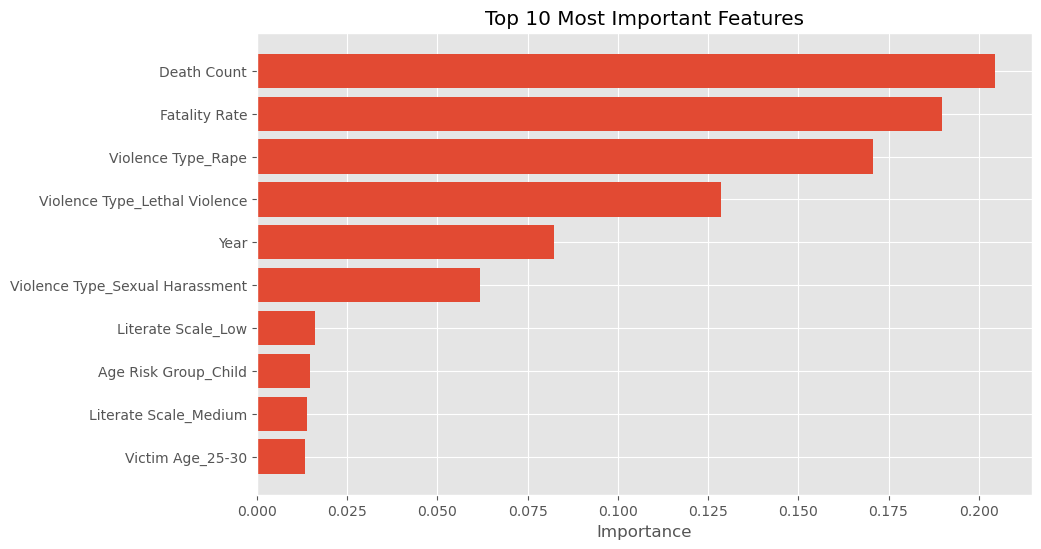

In [114]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")

plt.show()

### SAVING THE MODEL:

In [115]:
import joblib
joblib.dump (rf, "womens_violence_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### SAVING FEATURES FOR FLASK APPLICATION:

In [116]:
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [117]:
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']